# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

**used AI to confirm my understanding of the questions.

**1.** Adding a penalty discourages large coefficients, forcing the model to only keep features that genuinely help predictions and preventing overfitting.

**2.** Increasing alpha makes the model simpler with higher bias but lower variance. Decreasing alpha makes it behave more like OLS with lower bias but higher variance. Alpha lets you slide along that tradeoff.

**3.** LASSO uses absolute value of coefficients, Ridge uses squared values. LASSO can shrink coefficients to exactly zero, performing feature selection. Ridge only shrinks them close to zero, keeping all features.

**4.** We z-score normalize so the penalty treats all features equally. Without scaling, features with larger scales would get penalized more unfairly.

**5.** Using cross-validation, you try a grid of alpha values and pick the one with the lowest cross-validated MSE.

**6.** No. You only evaluate using prediction error (MSE), not the penalty term. The penalty is only used during training, not evaluation.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

## (1)a&b

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [2]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

#impoting data
cars = pd.read_csv("/Users/romangilbert/ml_container/undergrad_ml/data/cars_hw.csv")
#creating new feature for the age of the car
cars['Age'] = 2024 - cars['Make_Year']

#select the two features
X = cars[['Mileage_Run', 'Age']]

#creating third degree polynomial expansion
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

#z-score normalize with standardscaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

#put back into a DataFrame with feature names
X_final = pd.DataFrame(X_scaled, columns=poly.get_feature_names_out(['Mileage_Run', 'Age']))

## 2)

In [3]:
from sklearn.linear_model import LinearRegression
# target variable
y = cars['Price'] #i assume price is the target

# fit linear regression on scaled polynomial features
lr = LinearRegression()
lr.fit(X_scaled, y)

# put coefficients into a readable df
coef_df = pd.DataFrame({
    'Feature': poly.get_feature_names_out(['Mileage_Run', 'Age']),
    'Coefficient': lr.coef_
})

print(coef_df)

             Feature   Coefficient
0        Mileage_Run  6.686165e+05
1                Age -1.841941e+05
2      Mileage_Run^2 -1.494679e+05
3    Mileage_Run Age -1.251592e+06
4              Age^2  2.156399e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  2.833392e+05
7  Mileage_Run Age^2  5.280829e+05
8              Age^3 -1.389370e+05


The sign between mileage_run and age is negative.

## (3)

In [4]:
import numpy as np
from sklearn.linear_model import LassoCV

# define alpha grid
alphas = np.logspace(1, 3, 20)

# fitting LassoCV with 20-fold cross validation
lasso_cv = LassoCV(alphas=alphas, cv=20)
lasso_cv.fit(X_scaled, y)

# best alpha
print("Best alpha:", lasso_cv.alpha_)

Best alpha: 233.57214690901213


## (4)

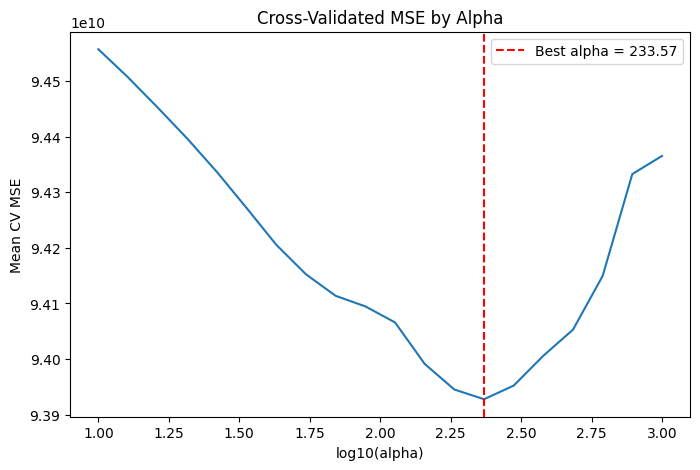

In [5]:
import matplotlib.pyplot as plt 
mse_mean = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(np.log10(lasso_cv.alphas_), mse_mean)
plt.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', label=f'Best alpha = {lasso_cv.alpha_:.2f}')
plt.xlabel('log10(alpha)')
plt.ylabel('Mean CV MSE')
plt.title('Cross-Validated MSE by Alpha')
plt.legend()
plt.show()

## (5)

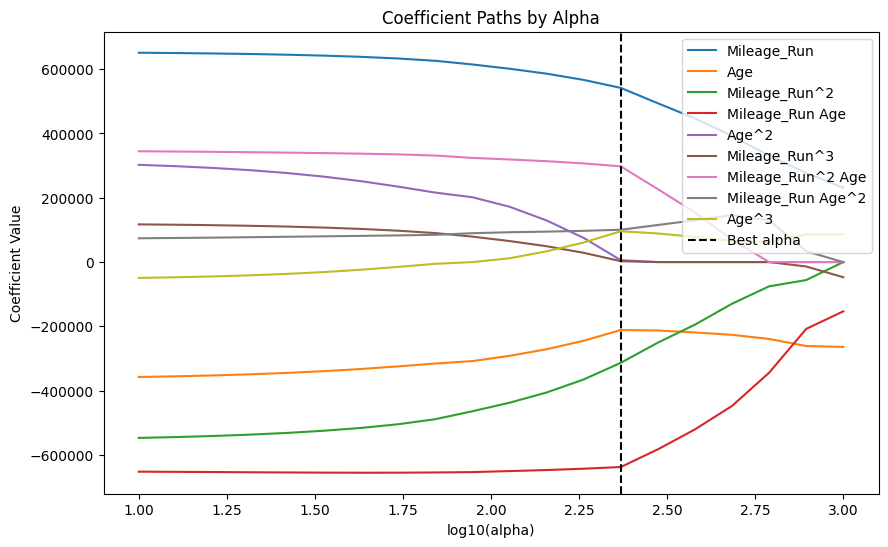

In [6]:
from sklearn.linear_model import Lasso
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

coef_paths = np.array([Lasso(alpha=a).fit(X_scaled, y).coef_ for a in alphas])

plt.figure(figsize=(10, 6))
for i, name in enumerate(feature_names):
    plt.plot(np.log10(alphas), coef_paths[:, i], label=name)
plt.axvline(np.log10(lasso_cv.alpha_), color='black', linestyle='--', label='Best alpha')
plt.xlabel('log10(alpha)')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Paths by Alpha')
plt.legend(loc='upper right')
plt.show()

## (6)

All 9 features were selected by LASSO. No features were set to zero, meaning the model retained the full polynomial expansion.

## (7)

In [7]:
comparison = pd.DataFrame({
    'Feature': feature_names,
    'OLS':     lr.coef_,
    'LASSO':   lasso_cv.coef_,
})
print(comparison)

             Feature           OLS          LASSO
0        Mileage_Run  6.686165e+05  541816.554848
1                Age -1.841941e+05 -211301.604371
2      Mileage_Run^2 -1.494679e+05 -313330.303312
3    Mileage_Run Age -1.251592e+06 -637593.936568
4              Age^2  2.156399e+05    5841.326277
5      Mileage_Run^3 -6.514490e+04    2735.702468
6  Mileage_Run^2 Age  2.833392e+05  297787.051885
7  Mileage_Run Age^2  5.280829e+05  100600.242401
8              Age^3 -1.389370e+05   95884.589970


Two coefficients increased in magntude (age and mileagerun^2) and two changed signs (mileagerun^3 and age^3). The rest seem to have shrunk.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

## (1)

In [8]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

#importing data
heart = pd.read_csv("../ml_container/undergrad_ml/data/heart_failure_clinical_records_dataset.csv")

In [9]:
#creating third degree polynomial expansion
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(heart[['age', 'ejection_fraction', 'serum_creatinine']])

#z-score normalize with standardscaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

poly_interact = PolynomialFeatures(interaction_only=True, include_bias=False)
X_interact = poly_interact.fit_transform(heart[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']])

#put back into a DataFrame with feature names
X_final = np.concatenate([X_scaled, X_interact], axis=1)

## (2)

In [10]:
# get feature names
continuous_names = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
interact_names = poly_interact.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])
all_feature_names = np.concatenate([continuous_names, interact_names])

y = heart['DEATH_EVENT']

#linear regression
lr = LinearRegression()
lr.fit(X_final, y)

coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr.coef_
})
print(coef_df)

                                   Feature  Coefficient
0                                      age     1.539156
1                        ejection_fraction    -2.192494
2                         serum_creatinine    -0.853588
3                                    age^2    -3.678654
4                    age ejection_fraction    -0.600918
5                     age serum_creatinine     1.841563
6                      ejection_fraction^2     3.430976
7       ejection_fraction serum_creatinine     2.673394
8                       serum_creatinine^2    -2.647041
9                                    age^3     1.993135
10                 age^2 ejection_fraction     0.908026
11                  age^2 serum_creatinine    -0.697522
12                 age ejection_fraction^2    -0.081206
13  age ejection_fraction serum_creatinine    -1.577665
14                  age serum_creatinine^2     1.284099
15                     ejection_fraction^3    -1.250341
16    ejection_fraction^2 serum_creatinine    -1

The coefficients for serum_creatinine, diabetes, and smoking are negative, which seems counterintuitive since these are known risk factors for death. This is likely due to multicollinearity; their effects get spread across correlated higher-order and interaction terms, making individual coefficients unstable.

## (3)

In [11]:
alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20)
lasso_cv.fit(X_final, y)

print("Best alpha:", lasso_cv.alpha_)

Best alpha: 0.005736152510448681


## (4)

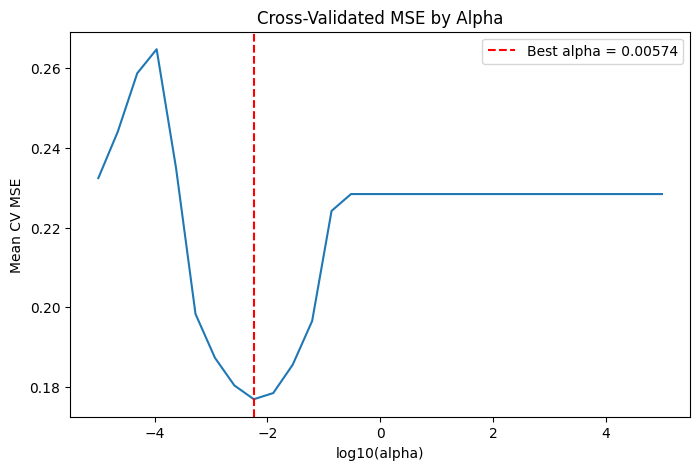

In [12]:
mse_mean = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(np.log10(lasso_cv.alphas_), mse_mean)
plt.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', label=f'Best alpha = {lasso_cv.alpha_:.5f}')
plt.xlabel('log10(alpha)')
plt.ylabel('Mean CV MSE')
plt.title('Cross-Validated MSE by Alpha')
plt.legend()
plt.show()

## (5)

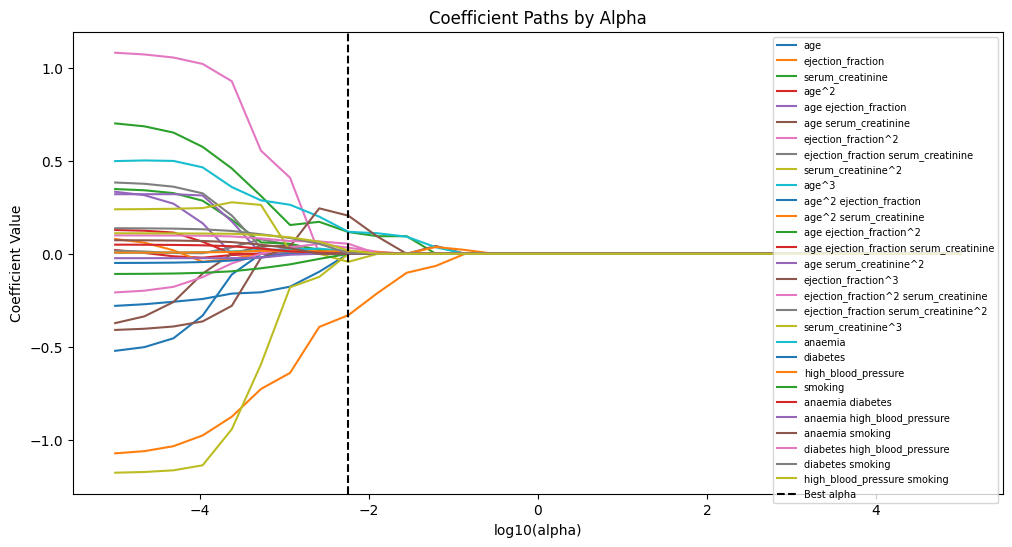

In [13]:
coef_paths = []
for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_final, y)
    coef_paths.append(lasso.coef_)
coef_paths = np.array(coef_paths)

plt.figure(figsize=(12, 6))
for i, name in enumerate(all_feature_names):
    plt.plot(np.log10(alphas), coef_paths[:, i], label=name)
plt.axvline(np.log10(lasso_cv.alpha_), color='black', linestyle='--', label='Best alpha')
plt.xlabel('log10(alpha)')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Paths by Alpha')
plt.legend(loc='upper right', fontsize=7)
plt.show()

## (6)

In [14]:
coef_df_lasso = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lasso_cv.coef_
})

print("SELECTED (non-zero):")
print(coef_df_lasso[coef_df_lasso['Coefficient'] != 0])
print("\nZEROED OUT:")
print(coef_df_lasso[coef_df_lasso['Coefficient'] == 0])

n_zero = (lasso_cv.coef_ == 0).sum()
print(f"\n{n_zero} / {len(all_feature_names)} features zeroed out ({n_zero/len(all_feature_names):.0%})")

comparison = pd.DataFrame({
    'Feature': all_feature_names,
    'OLS':     lr.coef_,
    'LASSO':   lasso_cv.coef_
})
print(comparison)

SELECTED (non-zero):
                                 Feature  Coefficient
1                      ejection_fraction    -0.329656
2                       serum_creatinine     0.116875
9                                  age^3     0.117992
15                   ejection_fraction^3     0.204822
16  ejection_fraction^2 serum_creatinine     0.032801
18                    serum_creatinine^3    -0.043266
19                               anaemia     0.014178
20                              diabetes     0.000607
21                   high_blood_pressure     0.013608
26          diabetes high_blood_pressure     0.053968
27                      diabetes smoking     0.003466
28           high_blood_pressure smoking     0.017805

ZEROED OUT:
                                   Feature  Coefficient
0                                      age         -0.0
3                                    age^2          0.0
4                    age ejection_fraction         -0.0
5                     age serum_creatini

** utilized AI to help analyze and understand the outputs completely

**Selection:** 12/29 features selected, 59% zeroed out.

**Magnitude increase:** None — all LASSO coefficients are smaller than OLS.

**Sign changes:** `serum_creatinine` and `ejection_fraction^3` both flipped sign. Notably, `serum_creatinine` becoming positive under LASSO makes more clinical sense.

**Bias-variance:** OLS overfits with 29 features, producing unstable signs. LASSO trades some bias for lower variance, giving a simpler and more interpretable model.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

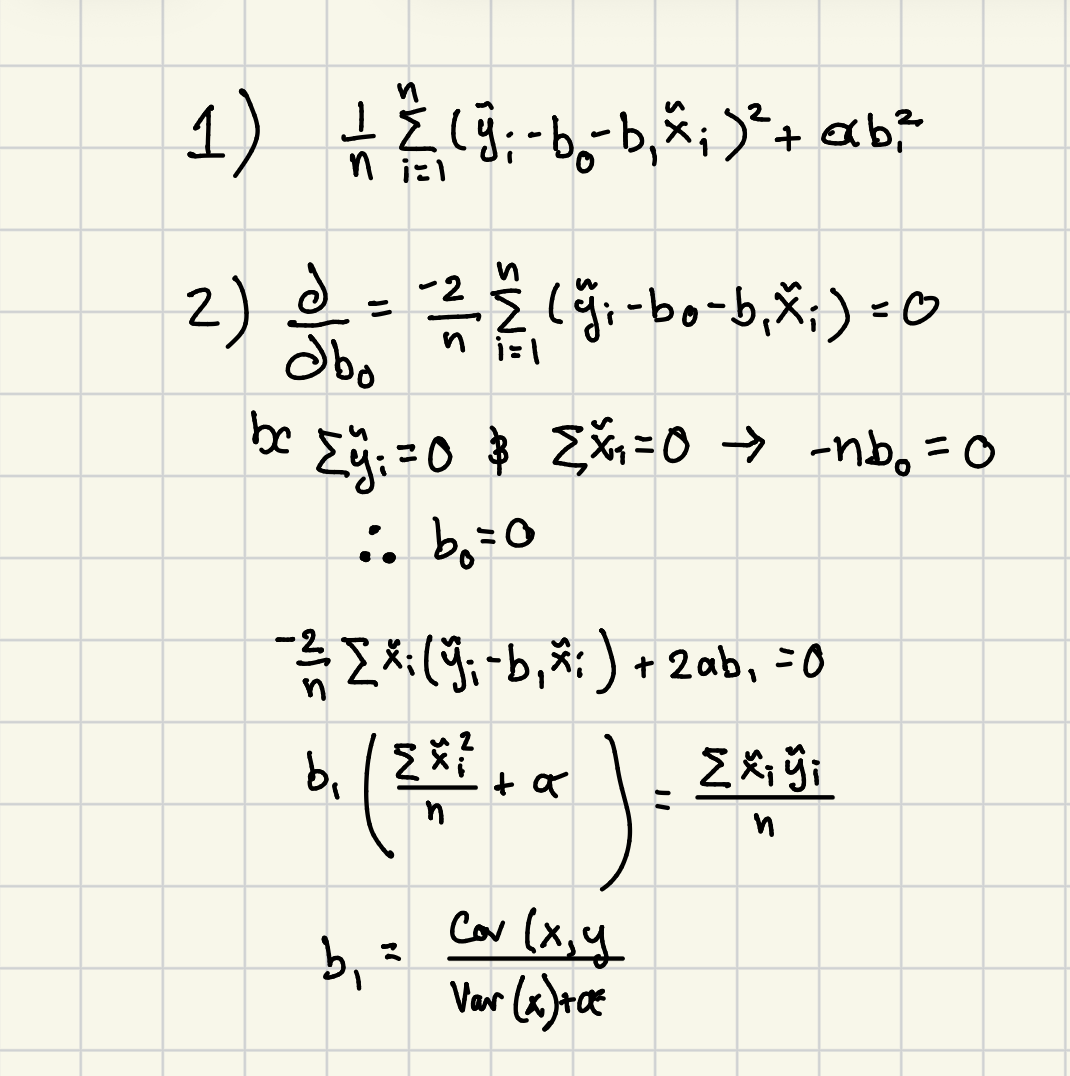

In [15]:
from IPython.display import Image
Image('/Users/romangilbert/Desktop/Mathematics For Ds 6.png')

3) As α increases, the denominator gets larger, so b1​ shrinks toward zero. The slope gets pulled toward zero.

4. The problem is $|b_1|$ is **not differentiable at $b_1 = 0$**, so you can't take a standard derivative there.

The solution is to use a subgradient instead. It turns out $b_1 = 0$ is optimal when:

$$|\text{Cov}(x, y)| \leq \frac{\alpha}{2}$$

If the relationship between $x$ and $y$ is weak enough relative to the penalty, LASSO zeros the coefficient out entirely. This is why LASSO does feature selection and Ridge does not.